# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [11]:
import numpy as np
import random


def jacobi(A, b, x, e: float, max_iter=1000) -> np.ndarray: 
    
    A = np.array(A)
    b = np.array(b)
    n = len(A)

    erros = []
    x0 = np.zeros(n)
    x_new = np.zeros(n)

    for i in range(max_iter):
        # atualiza depois de alterar todo o x_new (principal diff pra gauss seidel)
        x0 = x_new.copy() #não alterar o array de x_new

        for j in range(n):
            soma = sum(A[j][k] * x0[k] for k in range(n) if k != j)
            x_new[j] = (b[j] - soma)*(1/A[j][j])

        erro = np.linalg.norm(x_new - x0)
        erros.append(erro)

        if np.isnan(erro) or np.isinf(erro):
            print("Divergiu (overflow)")
            break

        a = 5
        if i >= a and all(erros[i-j] > erros[i-j-1] for j in range(a)):
            # erro cresceu nas últimas k iterações consecutivas
            print("Divergiu")
            break

        if erro < e:
            print(f"Convergiu em {i+1} iterações")
            break

    residuo = np.linalg.norm(A @ x - b)
    print(f"Resíduo: {residuo:.2e}")


    return erros
        


def jacobi_matricial(A, b, x, e:float, max_iter = 1000):
    
    A = np.array(A)
    b = np.array(b)
    n = len(A)

    D = np.diag(A)
    L = np.tril(A, k = -1) # posso usar?
    U = np.triu(A, k = 1) # muda complexidade?
    D_inv_vals = 1/D #ambas sao 1 dimensional
    D_inv = np.diag(D_inv_vals)

    #equação = D @ x_new = b - R @ x0

    erros = []
    x0 = np.zeros(n)
    x_new = np.zeros(n)
    R = L + U

    for i in range(max_iter):
        # atualiza depois de alterar todo o x_new (principal diff pra gauss seidel)
        x0 = x_new.copy() #não alterar o array de x_new

        soma = b - (R @ x0)
        x_new = D_inv @ soma

        erro = np.linalg.norm(x_new - x0)
        erros.append(erro)


        if np.isnan(erro) or np.isinf(erro):
            print("Divergiu (overflow)")
            break

        a = 5
        if i >= a and all(erros[i-j] > erros[i-j-1] for j in range(a)):
            # erro cresceu nas últimas k iterações consecutivas
            print("Divergiu")
            break

        if erro < e:
            print(f"Convergiu em {i+1} iterações")
            break

    residuo = np.linalg.norm(A @ x - b)
    print(f"Resíduo: {residuo:.2e}")


    return erros



def gauss_seidel(A, b, x, e: float, max_iter = 1000):

    A = np.array(A)
    b = np.array(b)
    n = len(A)

    erros = []
    x0 = np.zeros(n)
    x_new = np.zeros(n)

    for i in range(max_iter):
        x0 = x_new.copy() #não alterar o array de x_new
        
        for j in range(n):
            # atualiza enqt altera todo o x_new (principal diff pra gauss seidel)
            soma = sum(A[j][k] * x_new[k] for k in range(n) if k != j)
            x_new[j] = (b[j] - soma)*(1/A[j][j])

        erro = np.linalg.norm(x_new - x0)
        erros.append(erro)


        if np.isnan(erro) or np.isinf(erro):
            print("Divergiu (overflow)")
            break

        a = 5
        if i >= a and all(erros[i-j] > erros[i-j-1] for j in range(a)):
            # erro cresceu nas últimas k iterações consecutivas
            print("Divergiu")
            break

        if erro < e:
            print(f"Convergiu em {i+1} iterações")
            break

    residuo = np.linalg.norm(A @ x - b)
    print(f"Resíduo: {residuo:.2e}")
    

    return erros
    


def gauss_seidel_matricial(A, b, x, e:float, max_iter = 1000):

    A = np.array(A)
    b = np.array(b)
    n = len(A)

    D = np.diag(A)
    L = np.tril(A, k = -1) # posso usar?
    U = np.triu(A, k = 1) # muda complexidade?
    DL = np.diag(D) + L
    # equação = (D + L) @ x_new = (b - U @ x0)

    erros = []
    x0 = np.zeros(n)
    x_new = np.zeros(n)

    for i in range(max_iter):
        # atualiza depois de alterar todo o x_new (principal diff pra gauss seidel)
        x0 = x_new.copy() #não alterar o array de x_new

        x_new = np.linalg.solve(DL, b - U @ x0) 
        #explicar a diferenca desse pro linalg.inv (complexidade)

        erro = np.linalg.norm(x_new - x0)
        erros.append(erro)

        if np.isnan(erro) or np.isinf(erro):
            print("Divergiu (overflow)")
            break

        a = 5
        if i >= a and all(erros[i-j] > erros[i-j-1] for j in range(a)):
            # erro cresceu nas últimas k iterações consecutivas
            print("Divergiu")
            break

        if erro < e:
            print(f"Convergiu em {i+1} iterações")
            break

    residuo = np.linalg.norm(A @ x - b)
    print(f"Resíduo: {residuo:.2e}")

    return erros



Qual deveria ser a complexidade computacional do código que você escreveu?

Quebrando em funções:

i) `jacobi`: A função `jacobi` possui como principal característica a utilização de loops em vez de matrizes. Note que a parte mais crítica seria o loop que calcula x_new, onde temos um loop externo: n e um loop interno(sum): n. Assim, o custo é de O(n²). As outras partes da função, como `np.linalg.norm` e `x_new.copy()` possuem complexidade O(n). 

Como o algoritmo é iterativo, a complexidade computacional da função `jacobi` é O(k*n²), onde k é a quantidade de iterações até convergir.


ii) `gauss_seidel`:
A função `gauss_seidel` é muito semelhante à jacobi, com a principal diferença estando na forma como o vetor x é atualizado (utilizando os valores já atualizados dentro da mesma iteração). Porém, do ponto de vista de complexidade, isso não altera o custo. A parte mais crítica continua sendo o cálculo de x_new, onde há um loop externo de tamanho n e, dentro dele, um somatório que também percorre até n elementos. Logo, essa etapa possui custo O(n²). As demais operações, como o cálculo da norma e a cópia de vetores, possuem custo linear O(n).

Como o algoritmo é iterativo, a complexidade da função gauss_seidel é O(k*n²), onde k é o número de iterações.

iii) jacobi_matricial:
A função `jacobi_matricial` implementa o método de Jacobi utilizando operações matriciais. A etapa mais custosa acontece no cálculo de R @ x0, que corresponde a uma multiplicação matriz-vetor, com custo de O(n²). Em seguida, tem outra multiplicação matriz-vetor (D_inv @ soma), também com custo O(n²). Assim, o custo total por iteração continua O(n²).
As outras operações, como cálculo da norma e manipulação de vetores, possuem custo O(n), não mudando a ordem dominante.

Logo, a complexidade da função `jacobi_matricial` é O(k⋅n²), onde k é o número de iterações até convergência.

iv) `gauss_seidel_matricial`:
A função `gauss_seidel_matricial` difere muito das demais em termos de custo computacional. A etapa mais dominante ocorre na linha `np.linalg.solve(DL, b - U @ x0)`. Inicialmente, o produto matriz-vetor U @ x0 possui custo O(n²). No entanto, a chamada `np.linalg.solve` resolve um sistema linear geral, cujo custo é O(n³).
Assim, o custo por iteração passa a ser dominado por essa operação cúbica.

Logo, a complexidade total da função `gauss_seidel_matricial` é O(k*n³), onde k é o número de iterações até convergência.


Dessa forma, a complexidade computacional do meu código é O(k*n³), onde k é o número de iterações até convergência.

## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

========== TAMANHO = 2 x 2 ==========
Jacobi:
Convergiu em 90 iterações
Resíduo: 0.00e+00
--------
Jacobi Matricial:
Convergiu em 90 iterações
Resíduo: 0.00e+00
--------
Gauss-Seidel:
Convergiu em 42 iterações
Resíduo: 0.00e+00
--------
Gauss-Seidel Matricial:
Convergiu em 42 iterações
Resíduo: 0.00e+00
--------


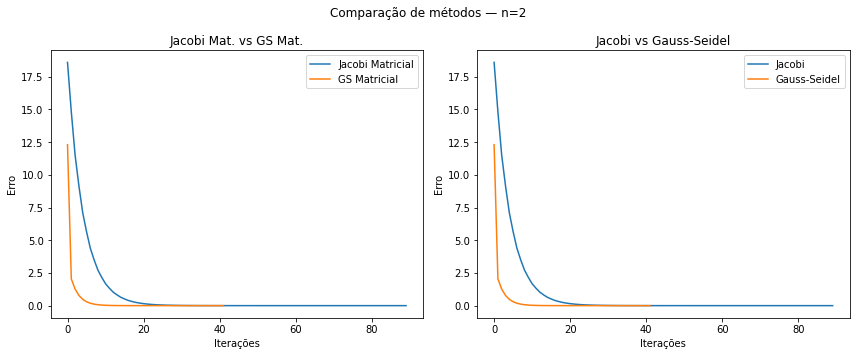

========== TAMANHO = 3 x 3 ==========
Jacobi:
Convergiu em 163 iterações
Resíduo: 7.94e-15
--------
Jacobi Matricial:
Convergiu em 163 iterações
Resíduo: 7.94e-15
--------
Gauss-Seidel:
Convergiu em 949 iterações
Resíduo: 7.94e-15
--------
Gauss-Seidel Matricial:
Convergiu em 949 iterações
Resíduo: 7.94e-15
--------


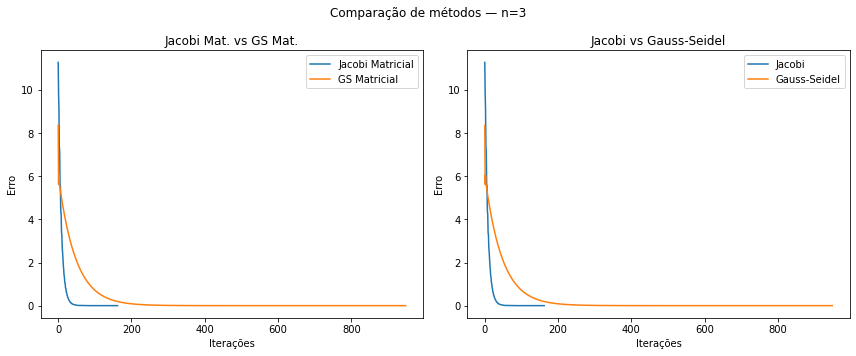

In [12]:
import matplotlib.pyplot as plt

def gerar_sistema_diag_dominante(n):
    # gera x
    x = [random.uniform(-10, 10) for _ in range(n)] 
    
    # monta matriz densa
    A = [[0.0]*n for _ in range(n)]
    for i in range(n): # acessa as linhas de A
        for j in range(n): # acessa as cols de A
            if i != j:
                A[i][j] = random.uniform(-10, 10)  # fora da diagonal
        
        # diag dominante
        soma_linha = sum(abs(A[i][j]) for j in range(n) if j != i)
        A[i][i] = soma_linha + random.uniform(0.1, 0.2) 

    # calcula b = Ax
    b = [0.0]*n 
    for i in range(n):
        for j in range(n):
            b[i] += A[i][j]*x[j]
    
    return A, b, x



def testes(tamanhos, func) -> None:

    for n in tamanhos:
        A, b, x_sol = func(n)
        A_np = np.array(A)
        b_np = np.array(b)

        print(f'========== TAMANHO = {n} x {n} ==========')
        # gerar funçoẽs
        print("Jacobi:")
        erros_j = jacobi(A_np, b_np, x_sol, 1e-8)
        print("-"*8)
        print("Jacobi Matricial:")
        erros_j_mat = jacobi_matricial(A_np, b_np, x_sol, 1e-8)
        print("-"*8)
        print("Gauss-Seidel:")
        erros_gs = gauss_seidel(A_np, b_np, x_sol, 1e-8)
        print("-"*8)
        print("Gauss-Seidel Matricial:")
        erros_gs_mat = gauss_seidel_matricial(A_np, b_np, x_sol, 1e-8)
        print("-"*8)

        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f"Comparação de métodos — n={n}")

        # Jacobi vs Gauss-Seidel
        axs[1].plot(erros_j, label="Jacobi")
        axs[1].plot(erros_gs, label="Gauss-Seidel")
        axs[1].set_title("Jacobi vs Gauss-Seidel")
        axs[1].set_xlabel("Iterações")
        axs[1].set_ylabel("Erro")
        axs[1].legend()

        # Jacobi matricial vs Gauss-Seidel matricial
        axs[0].plot(erros_j_mat, label="Jacobi Matricial")
        axs[0].plot(erros_gs_mat, label="GS Matricial")
        axs[0].set_title("Jacobi Mat. vs GS Mat.")
        axs[0].set_xlabel("Iterações")
        axs[0].set_ylabel("Erro")
        axs[0].legend()


        plt.tight_layout()
        plt.show()



tamanhos = [2, 3]

testes(tamanhos, gerar_sistema_diag_dominante)


Os elementos fora da diagonal de A foram gerados aleatoriamente em `[−10, 10]`, garantindo variabilidade sem instabilidade numérica. A diagonal principal foi definida como a soma dos valores absolutos dos demais elementos da linha somada com uma constante `C ∈ [0.1, 1]`, garantindo a dominância diagonal estrita (propriedade suficiente para a convergência dos dois métodos).


Além disso, quando construimos o vetor `b` como o produto `b=Ax`, onde x é um vetor gerado aleatoriamente, conseguimos garantir que o sistema linear tem uma solução conhecida. Isso permite verificar a convergência dos métodos e avaliar sua precisão de uma forma mais controlada.

Relembrando novamente que a função `gerar_sistema_diag_dominante` foi criada apenas para gerar os testes e observar a convergência de uma forma clara. 

É nítido que Gauss-Seidel converge mais rapidamente que Jacobi, as suas curvas de erro caem de forma mais brusca no início, enquanto Jacobi apresenta uma queda mais gradual. Isso ocorre porque GS utiliza os valores mais recentes disponíveis a cada iteração, o que propaga as correções de forma mais rápida. As curvas de Jacobi tem uma queda mais suave, mas as curvas de GS caem de forma mais brusca no início. 

Para C pequeno, os dois métodos convergem mais lentamente, já que `A[i][i]` fica só um pouco maior que a soma da linha. Quando C é grande, temos que os dois métodos convergem rapidamente, o que faz a diferença de Gauss Seidel e Jacobi "sumir".

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

========== TAMANHO = 3 x 3 ==========
Jacobi:
Divergiu
Resíduo: 0.00e+00
--------
Jacobi Matricial:
Divergiu
Resíduo: 0.00e+00
--------
Gauss-Seidel:
Divergiu
Resíduo: 0.00e+00
--------
Gauss-Seidel Matricial:
Divergiu
Resíduo: 0.00e+00
--------


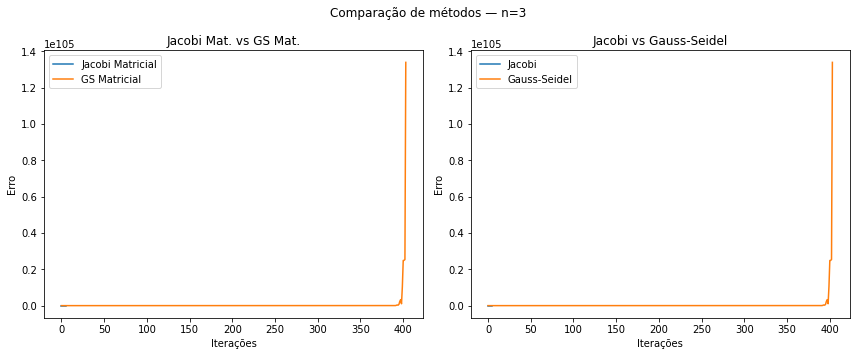

========== TAMANHO = 5 x 5 ==========
Jacobi:
Divergiu
Resíduo: 0.00e+00
--------
Jacobi Matricial:
Divergiu
Resíduo: 0.00e+00
--------
Gauss-Seidel:
Divergiu
Resíduo: 0.00e+00
--------
Gauss-Seidel Matricial:
Divergiu
Resíduo: 0.00e+00
--------


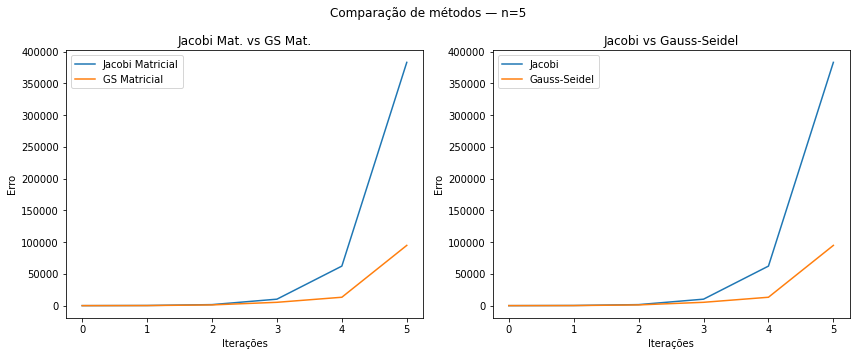

========== TAMANHO = 10 x 10 ==========
Jacobi:
Divergiu
Resíduo: 6.40e-15
--------
Jacobi Matricial:
Divergiu
Resíduo: 6.40e-15
--------
Gauss-Seidel:
Divergiu
Resíduo: 6.40e-15
--------
Gauss-Seidel Matricial:
Divergiu
Resíduo: 6.40e-15
--------


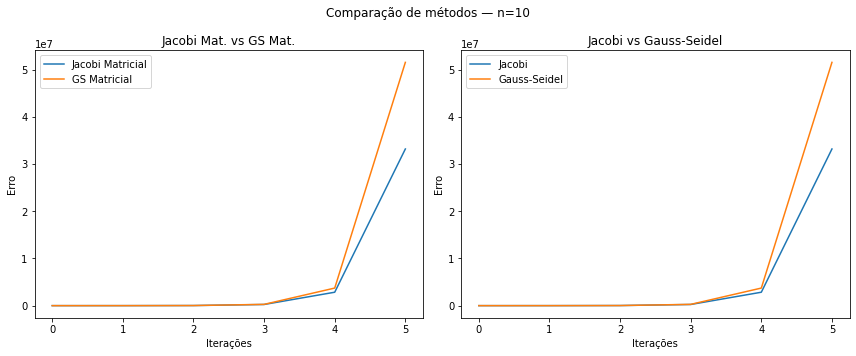

========== TAMANHO = 20 x 20 ==========
Jacobi:
Divergiu
Resíduo: 1.48e-14
--------
Jacobi Matricial:
Divergiu
Resíduo: 1.48e-14
--------
Gauss-Seidel:
Divergiu
Resíduo: 1.48e-14
--------
Gauss-Seidel Matricial:
Divergiu
Resíduo: 1.48e-14
--------


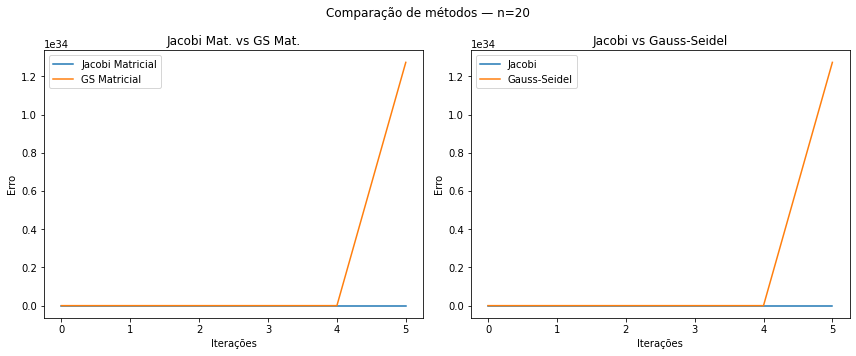

========== TAMANHO = 50 x 50 ==========
Jacobi:
Divergiu
Resíduo: 1.13e-13
--------
Jacobi Matricial:
Divergiu
Resíduo: 1.13e-13
--------
Gauss-Seidel:
Divergiu
Resíduo: 1.13e-13
--------
Gauss-Seidel Matricial:
Divergiu
Resíduo: 1.13e-13
--------


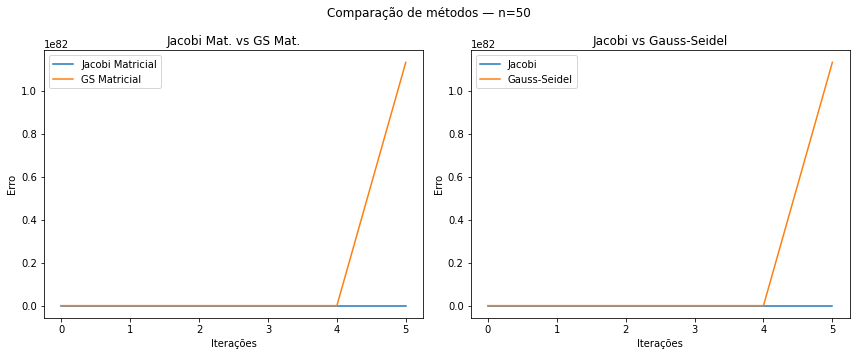

========== TAMANHO = 100 x 100 ==========
Jacobi:
Divergiu
Resíduo: 5.23e-13
--------
Jacobi Matricial:
Divergiu
Resíduo: 5.23e-13
--------
Gauss-Seidel:
Divergiu
Resíduo: 5.23e-13
--------
Gauss-Seidel Matricial:
Divergiu
Resíduo: 5.23e-13
--------


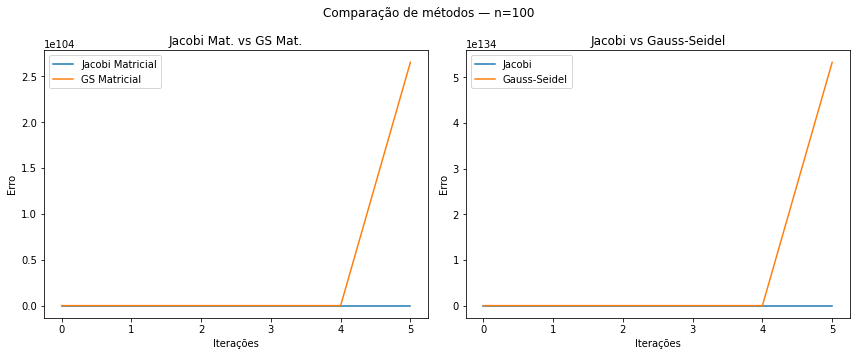

In [15]:
def gerar_sistema(n):
    # gera x
    x = [random.uniform(1, 5) for _ in range(n)]

    # monta matriz tridiagonal
    A = np.random.rand(n,n)

    # calcula b = Ax
    b = [0]*n
    for i in range(n):
        for j in range(n):
            b[i] += A[i][j]*x[j]

    return A, b, x

tamanhos = [3, 5, 10, 20, 50, 100]

testes(tamanhos, gerar_sistema)

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?

In [ ]:
# Código (gerando possivelmente gráficos ou tabelas)

(Comentários)

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

(Explique suas ideias, verifique abaixo)

In [ ]:
# Código

## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à matriz $A$ acima?  O que acontece se esta perturbação acontecer apenas fora da diagonal?

In [ ]:
# Código

(Comentários)